# MRS Artefact Dataset — Exploration & Unified Label Construction

**Project goal**: Construct a fully-labelled unified dataset of brain tumour MRS spectra for training synthetic artefact generation models.

---

## Verified data structure

| File | Dataset | N spectra | Quality labels | Tissue labels |
|---|---|---|---|---|
| `Multiclass_RMSE_QUEST.mat` | eTumour + INTERPRET | 1180 short + 977 long | Good/Poor/Bad | none |
| `1TE-ShortMRS_corregido_.xml` | INTERPRET only | 304 short-TE | none | yes |
| `Matriz_originales.xml` | eTumour only | 777 short-TE | none | yes |
| `Listado_etumour2.txt` | eTumour metadata | — | none | WHO text |

## ID encoding in the MAT file
517-column layout: `[case_id, svs_code, exp_idx, SNR, WBW, spectrum×512]`
- **eTumour**: `col0` = numeric e.g. `2024` → `et2024`
- **INTERPRET**: `col0` = `777_770_000 + N` → XML case `I{N:04d}`

## Three-tier tissue assignment
1. **eTumour — exact spectrum match** against `Matriz_originales.xml` (MSE < 1e-4)
2. **eTumour — pathology file fallback** via `et####` → WHO text → tissue code
3. **INTERPRET** — decode `col0 − 777_770_000 → N`, join `I{N:04d}` in INTERPRET XML

**Achieved coverage**: ~85% of short-TE rows tissue-labelled. Remaining rows still usable for quality-only modelling.

---
## 0. Setup

In [4]:
import numpy as np
import pandas as pd
import scipy.io as sio
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import re
from pathlib import Path

# ── Point this at wherever the uploaded files live ────────────────────────
DATA_DIR = Path("../../../projects/yani_etumour_reconstruction/")
# ─────────────────────────────────────────────────────────────────────────

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# PPM axis: 512 points from -2.7 to 7.1 ppm
PPM = np.linspace(-2.7, 7.1, 512)

TISSUE_FULL = {
    "gl":"Glioblastoma", "mm":"Metastasis", "me":"Meningioma",
    "a2":"Astrocytoma gr.2", "a3":"Anaplastic astrocytoma",
    "od":"Oligodendroglioma", "pi":"Pilocytic astrocytoma",
    "oa":"Oligoastrocytoma", "no":"Normal brain",
    "pn":"Pituitary adenoma", "ra":"Radiation necrosis",
    "ly":"Lymphoma", "ab":"Abscess", "sc":"Schwannoma",
    "hb":"Haemangioblastoma", "mb":"Medulloblastoma",
    "ep":"Ependymoma", "cp":"Craniopharyngioma",
    "gg":"Ganglioglioma", "cpp":"Choroid plexus papilloma", "nb":"Neuroblastoma",
}

WHO_TO_TISSUE = {
    "GLIOBLASTOMA":"gl", "ANAPLASTIC ASTROCYTOMA":"a3",
    "ASTROCYTOMA":"a2", "FIBRILLARY ASTROCYTOMA":"a2",
    "PILOCYTIC ASTROCYTOMA":"pi", "OLIGODENDROGLIOMA":"od",
    "ANAPLASTIC OLIGODENDROGLIOMA":"od", "OLIGOASTROCYTOMA":"oa",
    "ANAPLASTIC OLIGOASTROCYTOMA":"oa", "MENINGIOMA":"me",
    "MENINGOTHELIAL MENINGIOMA":"me", "FIBROUS MENINGIOMA":"me",
    "TRANSITIONAL MENINGIOMA":"me", "PSAMMOMATOUS MENINGIOMA":"me",
    "SECRETORY MENINGIOMA":"me", "MICROCYSTIC MENINGIOMA":"me",
    "CLEAR CELL MENINGIOMA":"me", "ATYPICAL MENINGIOMA":"me",
    "METASTASIS":"mm", "MALIGNANT LYMPHOMAS":"ly", "LYMPHOMA":"ly",
    "PITUITARY ADENOMA":"pn", "MEDULLOBLASTOMA":"mb",
    "EPENDYMOMA":"ep", "ANAPLASTIC EPENDYMOMA":"ep",
    "SCHWANNOMA":"sc", "HAEMANGIOBLASTOMA":"hb", "HAEMANGIOPERICYTOMA":"hb",
    "CRANIOPHARYNGIOMA":"cp", "ADAMANTINOMATOUS CRANIOPHARYNGIOMA":"cp",
    "GANGLIOGLIOMA":"gg", "GANGLIOCYTOMA":"gg",
    "CHOROID PLEXUS PAPILLOMA":"cpp", "NEUROBLASTOMA":"nb",
}

QUALITY_ORDER  = ["Good", "Poor", "Bad"]
QUALITY_COLORS = {"Good": "#2a9d8f", "Poor": "#e9c46a", "Bad": "#e76f51"}
QUALITY_MAP    = {"Good": 0, "Poor": 1, "Bad": 2}

print("Setup complete.")

Setup complete.


---
## 1. Build tissue-label lookup tables

In [2]:
def who_to_code(text):
    """Map a verbose WHO pathology string to a short tissue code."""
    if not text or text.strip() in ("", "NA", "0"):
        return None
    clean = re.sub(r"\d{4}/\d", "", text).strip().upper()
    if clean in WHO_TO_TISSUE:
        return WHO_TO_TISSUE[clean]
    for key, code in WHO_TO_TISSUE.items():
        if key in clean:
            return code
    return "unknown"


def parse_xml_spectra(xml_path):
    """Return spectra (N,512), IDs, tissue codes from an MRS XML file."""
    tree = ET.parse(xml_path)
    specs, ids, tissues = [], [], []
    for case in tree.getroot().findall("Case"):
        pts = np.array(
            case.find(".//Points").text.strip().split(), dtype=np.float32
        )
        specs.append(pts)
        ids.append(case.get("ID"))
        tissues.append(case.find("Tissue").get("Type", "").strip())
    return np.vstack(specs), ids, tissues


# 1a. Pathology file: et_id → tissue_code
et_tissue_from_path = {}
with open(DATA_DIR / "Listado_etumour2.txt", "rb") as f:
    path_text = f.read().decode("iso-8859-1")
for line in path_text.splitlines():
    parts = [p.strip() for p in line.split("\t")]
    if not parts or not re.match(r"^et\d+", parts[0]):
        continue
    consensus = parts[3] if len(parts) > 3 else ""
    original  = parts[5] if len(parts) > 5 else ""
    label = consensus if consensus not in ("", "NA", "0") else original
    code  = who_to_code(label)
    if code:
        et_tissue_from_path[parts[0]] = code
print(f"Pathology file: {len(et_tissue_from_path)} et_id → tissue mappings")

# 1b. eTumour XML: reference spectra for exact-match tier
xml_et_specs, xml_et_ids, xml_et_tis = parse_xml_spectra(
    DATA_DIR / "Matrices_Yeni_XML/Matriz_originales.xml"
)
print(f"Matrices_Yeni_XML/Matriz_originales.xml: {xml_et_specs.shape[0]} spectra")

# 1c. INTERPRET XML: numeric case number → tissue_code
_, interp_ids, interp_tis = parse_xml_spectra(
    DATA_DIR / "Matrices_y_datos_tesis_Yeni/1TE-ShortMRS(corregido).xml"
)
interp_num_to_tissue = {int(k[1:]): v for k, v in zip(interp_ids, interp_tis)}
print(f"INTERPRET XML: {len(interp_num_to_tissue)} case → tissue mappings")

Pathology file: 1290 et_id → tissue mappings
Matrices_Yeni_XML/Matriz_originales.xml: 777 spectra
INTERPRET XML: 304 case → tissue mappings


---
## 2. Load and label MAT spectra

In [3]:
INTERPRET_OFFSET = 777_770_000
EXACT_MSE_THRESH = 1e-4


def assign_tissue(raw_id, spectrum):
    """
    Three-tier tissue assignment for one spectrum.
    Returns (tissue_code_or_None, assignment_method_string).
    """
    if raw_id > 100_000:  # INTERPRET
        case_num = raw_id - INTERPRET_OFFSET
        return interp_num_to_tissue.get(case_num), "interpret_id"

    # eTumour tier 1: exact spectrum match
    mse = np.mean((xml_et_specs - spectrum) ** 2, axis=1)
    if mse.min() < EXACT_MSE_THRESH:
        return xml_et_tis[mse.argmin()], "etumour_spectrum_match"

    # eTumour tier 2: pathology file
    tissue = et_tissue_from_path.get(f"et{raw_id}")
    return tissue, "etumour_pathology_fallback"


def load_te_block(mat, te_key, rmse_key, echo_time_label):
    """
    Parse one echo-time block from Multiclass_RMSE_QUEST.mat.
    Returns a DataFrame with one row per spectrum.
    """
    data    = mat[te_key]                       # (N, 517)
    rmse    = mat[rmse_key]                     # (N, 4)
    qlabels = np.array(
        [str(l.flat[0]) for l in mat[f"{te_key}_label"].flatten()]
    )
    raw_ids = data[:, 0].astype(int)
    spectra = data[:, 5:].astype(np.float32)

    rows = []
    for i in range(len(data)):
        rid    = raw_ids[i]
        tissue, method = assign_tissue(rid, spectra[i])
        is_i   = rid > 100_000
        cnum   = rid - INTERPRET_OFFSET if is_i else rid
        cid    = f"I{int(cnum):04d}" if is_i else f"et{rid}"
        q      = qlabels[i]
        rows.append({
            "case_id"        : cid,
            "exp_idx"        : int(data[i, 2]),
            "snr"            : float(data[i, 3]),
            "wbw"            : float(data[i, 4]),
            "quality"        : q,
            "quality_code"   : QUALITY_MAP[q],
            "is_artefactual" : int(q != "Good"),
            "quest_rmse"     : float(rmse[i, 3]),
            "echo_time"      : echo_time_label,
            "dataset"        : "INTERPRET" if is_i else "eTumour",
            "tissue_code"    : tissue,
            "tissue_name"    : TISSUE_FULL.get(str(tissue), str(tissue)) if tissue else None,
            "tissue_method"  : method,
            "spectrum"       : spectra[i],
        })
    return pd.DataFrame(rows)


mat = sio.loadmat(DATA_DIR / "Matrices_y_datos_tesis_Yeni/Multiclass_RMSE_QUEST.mat")

print("Loading short-TE block (this takes ~30 s due to spectrum matching)...")
short_df = load_te_block(mat, "ShortTE", "RMSE_ShortTE", "short")
print(f"  {len(short_df):,} rows")

print("Loading long-TE block...")
long_df = load_te_block(mat, "LongTE", "RMSE_LongTE", "long")
print(f"  {len(long_df):,} rows")

Loading short-TE block (this takes ~30 s due to spectrum matching)...
  1,180 rows
Loading long-TE block...
  977 rows


---
## 3. Assemble unified dataset

In [4]:
all_df = pd.concat([short_df, long_df], ignore_index=True)

# Deduplicate on (case_id, echo_time, exp_idx)
all_df["row_uid"] = (
    all_df["case_id"] + "__" + all_df["echo_time"] + "__" + all_df["exp_idx"].astype(str)
)
n_before = len(all_df)
all_df = all_df.drop_duplicates(subset="row_uid").reset_index(drop=True)
print(f"Rows after deduplication: {len(all_df):,}  (dropped {n_before - len(all_df)})")

def is_labelled(s): return pd.notna(s) and str(s) not in ("unknown", "nan", "None")
tc_ok = all_df["tissue_code"].apply(is_labelled)

print("=" * 35)
print("UNIFIED DATASET — LABEL COVERAGE AUDIT")
print("=" * 35)
for te, grp in all_df.groupby("echo_time"):
    n     = len(grp)
    q_vc  = grp["quality"].value_counts().reindex(QUALITY_ORDER, fill_value=0)
    tc_n  = grp["tissue_code"].apply(is_labelled).sum()
    print(f"\n{te.upper()}-TE  (n={n:,})")
    print(f"  Quality:         {dict(zip(QUALITY_ORDER, q_vc))}")
    print(f"  Tissue-labelled: {tc_n}/{n} ({100*tc_n/n:.1f}%)")
    print(f"  Methods:         {dict(grp.tissue_method.value_counts())}")
    print(f"  SNR range:       {grp.snr[grp.snr>0].min():.1f} – {grp.snr.max():.1f}")
    print(f"  RMSE range:      {grp.quest_rmse.min():.4f} – {grp.quest_rmse.max():.4f}")

Rows after deduplication: 2,129  (dropped 28)
UNIFIED DATASET — LABEL COVERAGE AUDIT

LONG-TE  (n=973)
  Quality:         {'Good': 824, 'Poor': 38, 'Bad': 111}
  Tissue-labelled: 788/973 (81.0%)
  Methods:         {'etumour_pathology_fallback': np.int64(618), 'interpret_id': np.int64(353), 'etumour_spectrum_match': np.int64(2)}
  SNR range:       0.0 – 88.3
  RMSE range:      0.0287 – 0.1936

SHORT-TE  (n=1,156)
  Quality:         {'Good': 961, 'Poor': 46, 'Bad': 149}
  Tissue-labelled: 939/1156 (81.2%)
  Methods:         {'etumour_spectrum_match': np.int64(511), 'interpret_id': np.int64(429), 'etumour_pathology_fallback': np.int64(216)}
  SNR range:       0.0 – 77.6
  RMSE range:      0.0268 – 0.1949


In [5]:
# Quality × tissue cross-table with artefact rate
ct = pd.crosstab(
    all_df["tissue_code"].fillna("UNLABELLED"),
    all_df["quality"],
    margins=True
)
ct["artefact_%"] = (
    (ct.get("Poor", 0) + ct.get("Bad", 0)) / ct["All"] * 100
).round(1)
print(ct.to_string())

quality      Bad  Good  Poor   All  artefact_%
tissue_code                                   
UNLABELLED    59   254    13   326        22.1
a2            13   150    10   173        13.3
a3             5    53     1    59        10.2
ab             0    16     0    16         0.0
cp             3     0     3     6       100.0
cpp            1    13     0    14         7.1
ep             3    26     1    30        13.3
gg             1     9     1    11        18.2
gl            58   454    19   531        14.5
hb             1    15     1    17        11.8
ly             2    30     2    34        11.8
mb             2    44     2    48         8.3
me            23   172     7   202        14.9
mm            27   193     6   226        14.6
nb             2     2     0     4        50.0
no             3    39     0    42         7.1
oa             6    48     2    56        14.3
od             7    91     4   102        10.8
pi            17    69     4    90        23.3
pn           

---
## 4. Spectrum quality visualisation

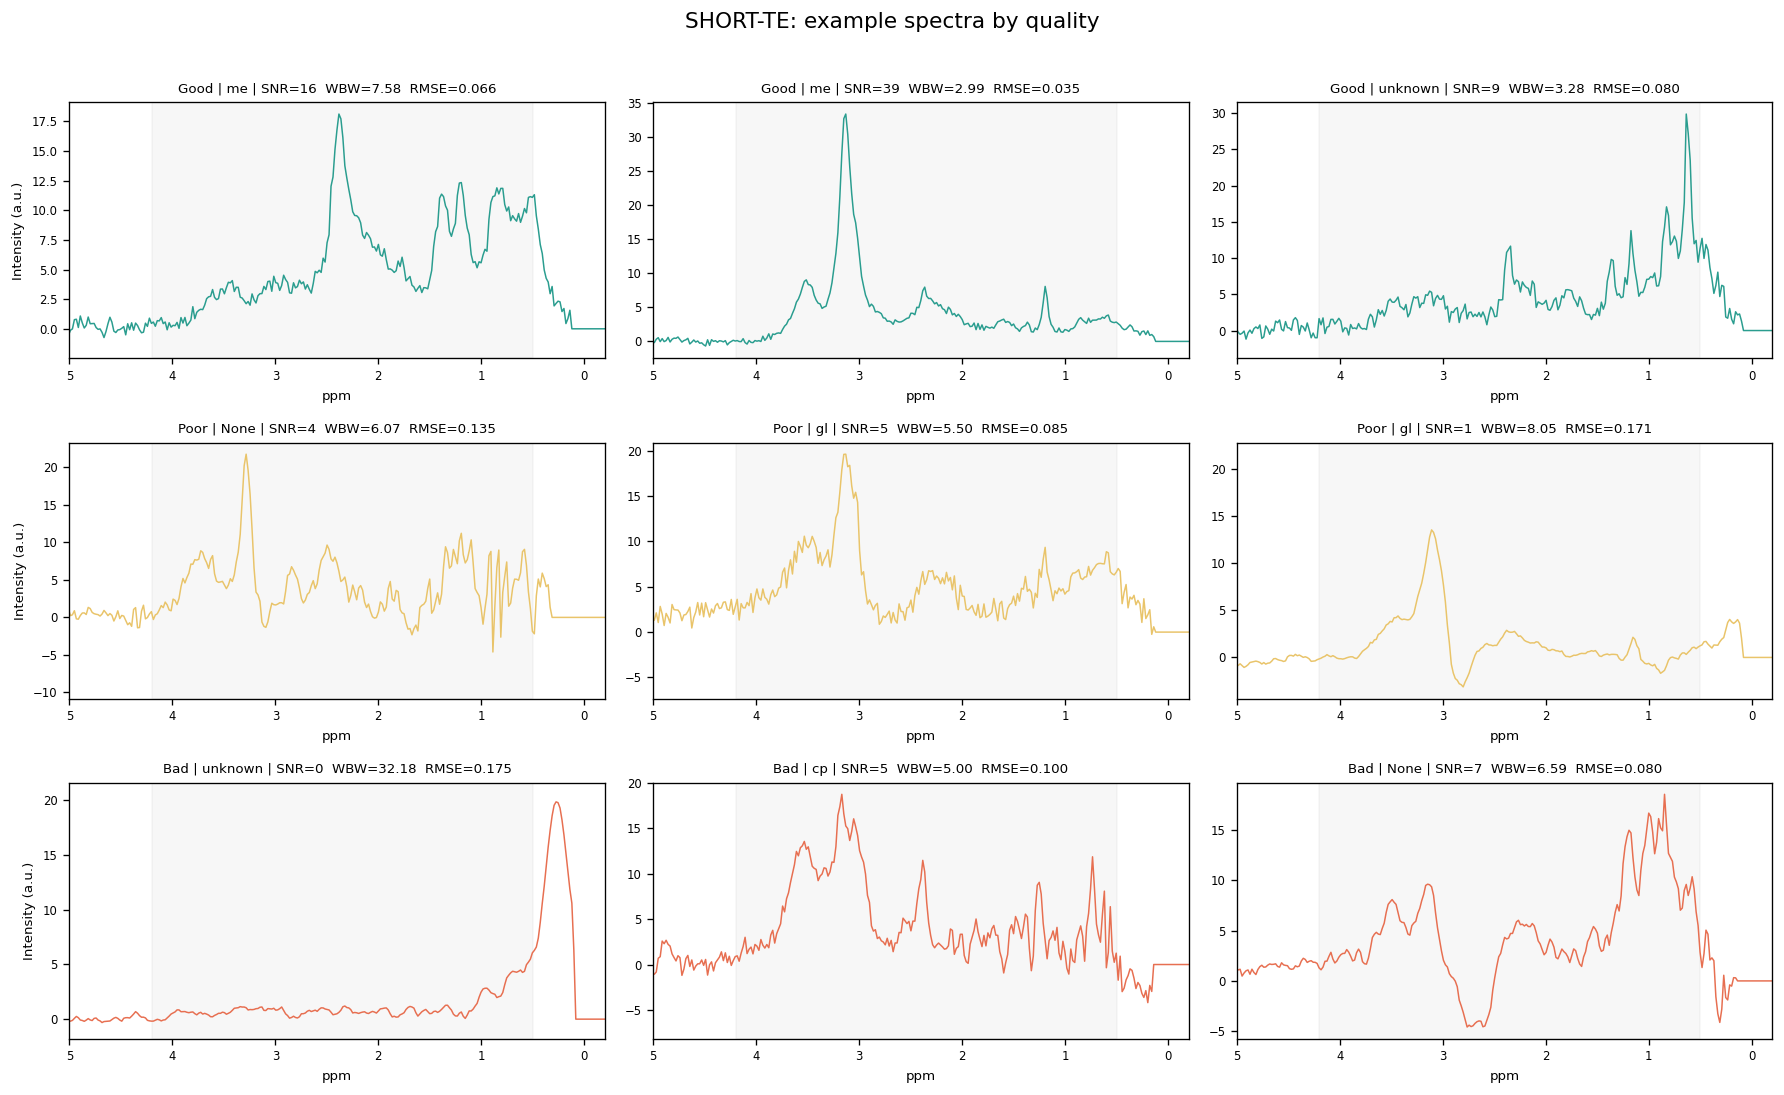

In [6]:
def plot_quality_examples(df, te_label, n_each=3, seed=42):
    grp = df[df["echo_time"] == te_label]
    fig, axes = plt.subplots(3, n_each, figsize=(5 * n_each, 9))
    fig.suptitle(f"{te_label.upper()}-TE: example spectra by quality", fontsize=13, y=1.01)
    for row_i, quality in enumerate(QUALITY_ORDER):
        subset  = grp[grp["quality"] == quality]
        samples = subset.sample(min(n_each, len(subset)), random_state=seed)
        color   = QUALITY_COLORS[quality]
        for col_i, (_, row) in enumerate(samples.iterrows()):
            ax = axes[row_i, col_i]
            ax.plot(PPM, row["spectrum"], color=color, lw=0.9)
            ax.invert_xaxis(); ax.set_xlim(5.0, -0.2)
            tc = row.get("tissue_code", "?")
            ax.set_title(
                f"{quality} | {tc} | SNR={row.snr:.0f}  WBW={row.wbw:.2f}  RMSE={row.quest_rmse:.3f}",
                fontsize=8
            )
            ax.set_xlabel("ppm", fontsize=8)
            if col_i == 0: ax.set_ylabel("Intensity (a.u.)", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.axvspan(0.5, 4.2, alpha=0.06, color="gray")
    plt.tight_layout()
    plt.savefig(f"spectra_quality_{te_label}TE.png", bbox_inches="tight")
    plt.show()

plot_quality_examples(all_df, "short")

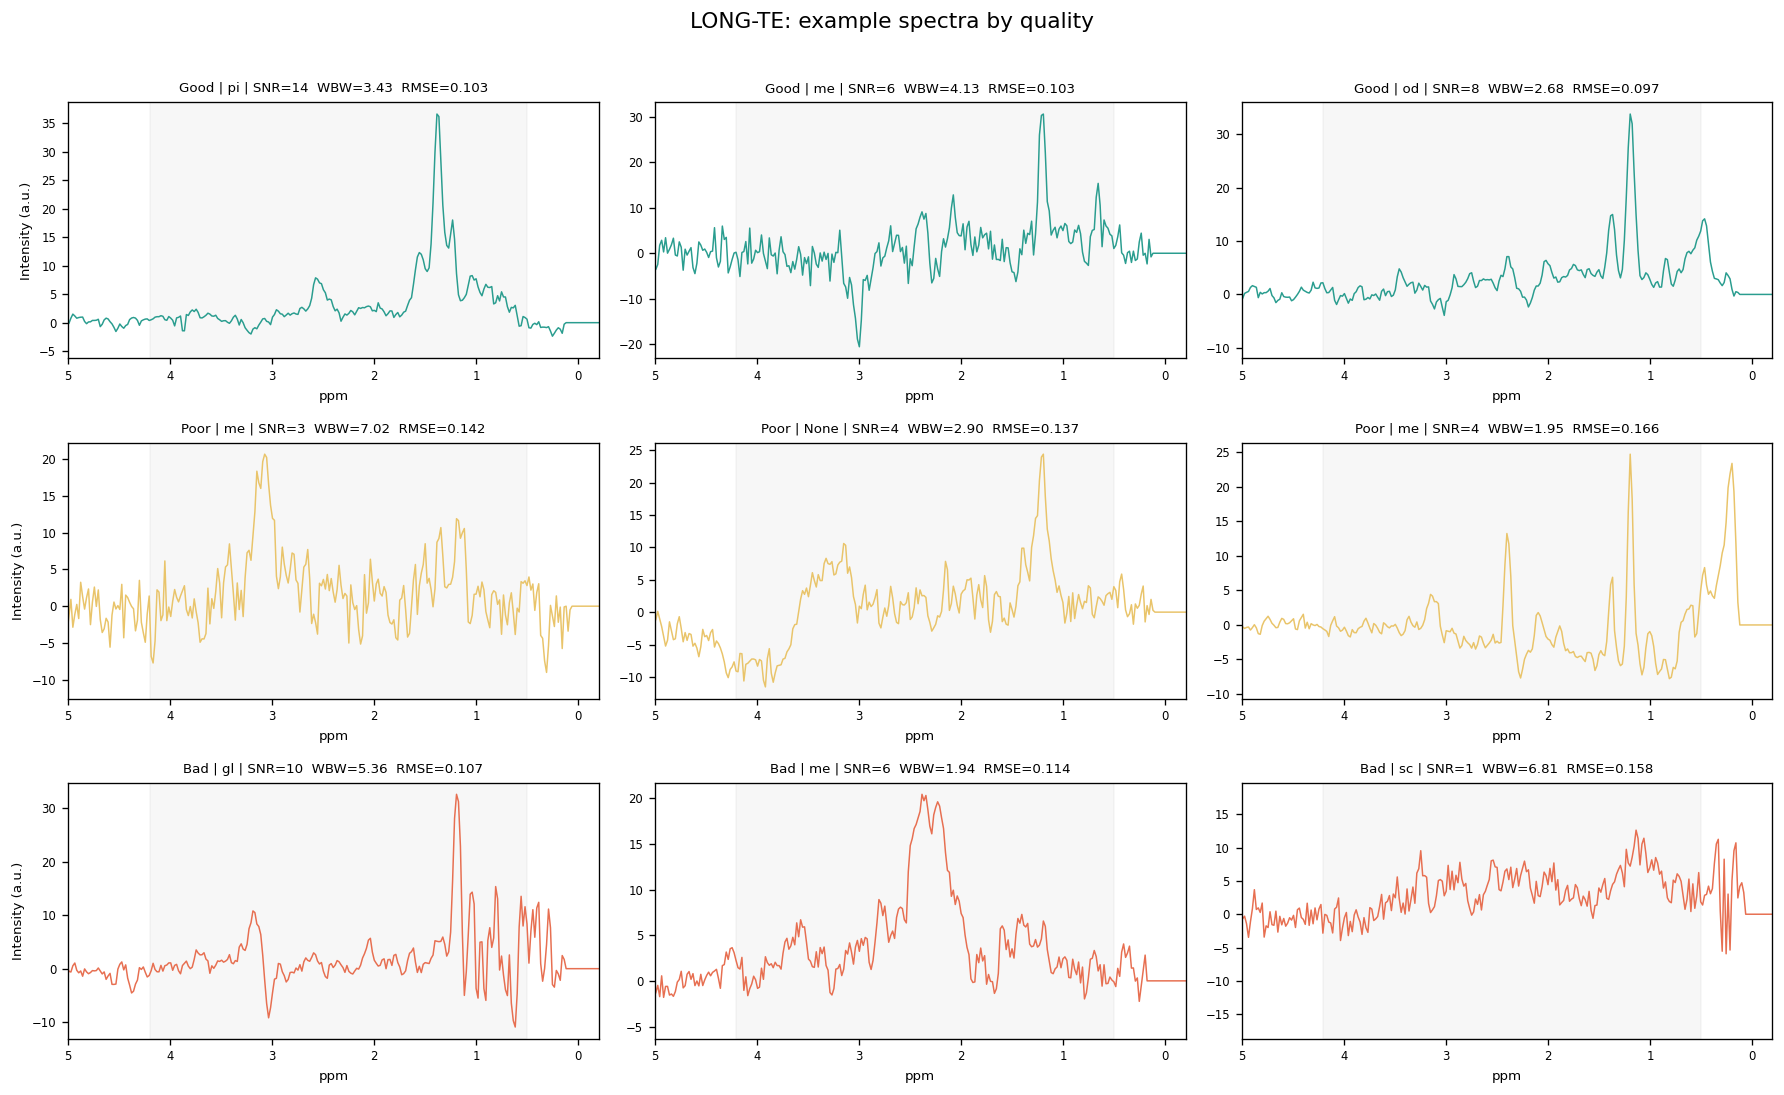

In [7]:
plot_quality_examples(all_df, "long")

---
## 5. Mean spectra per quality class

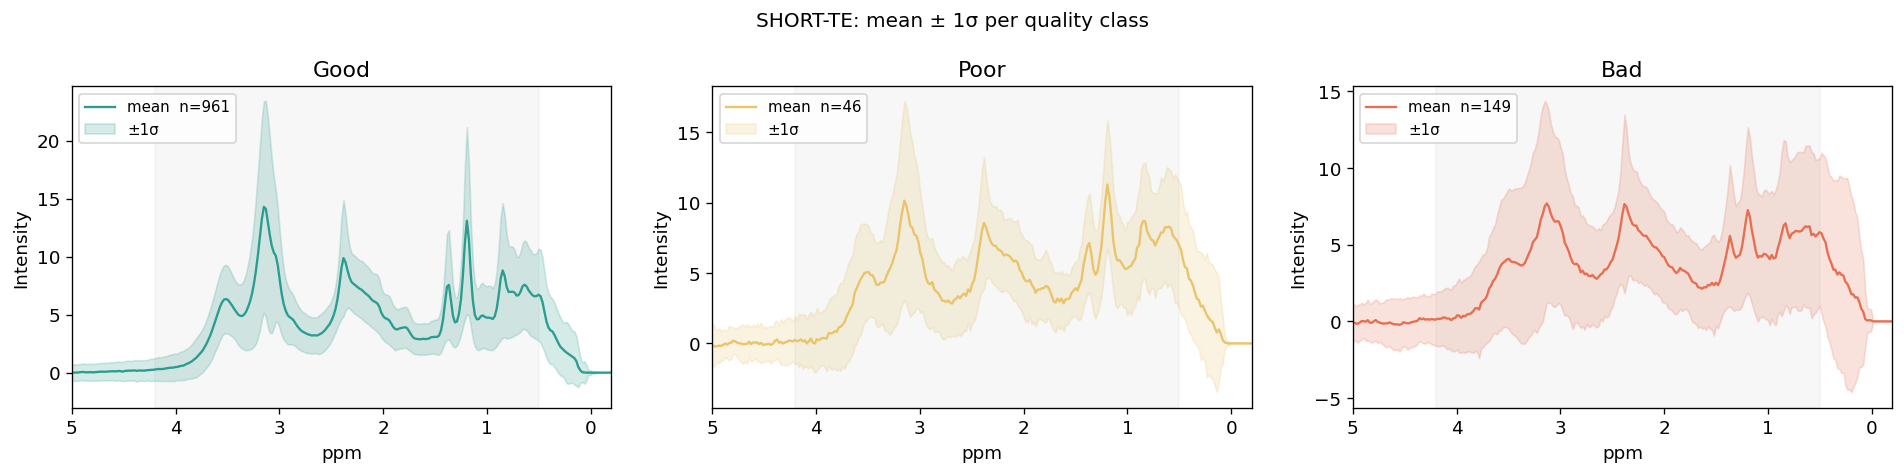

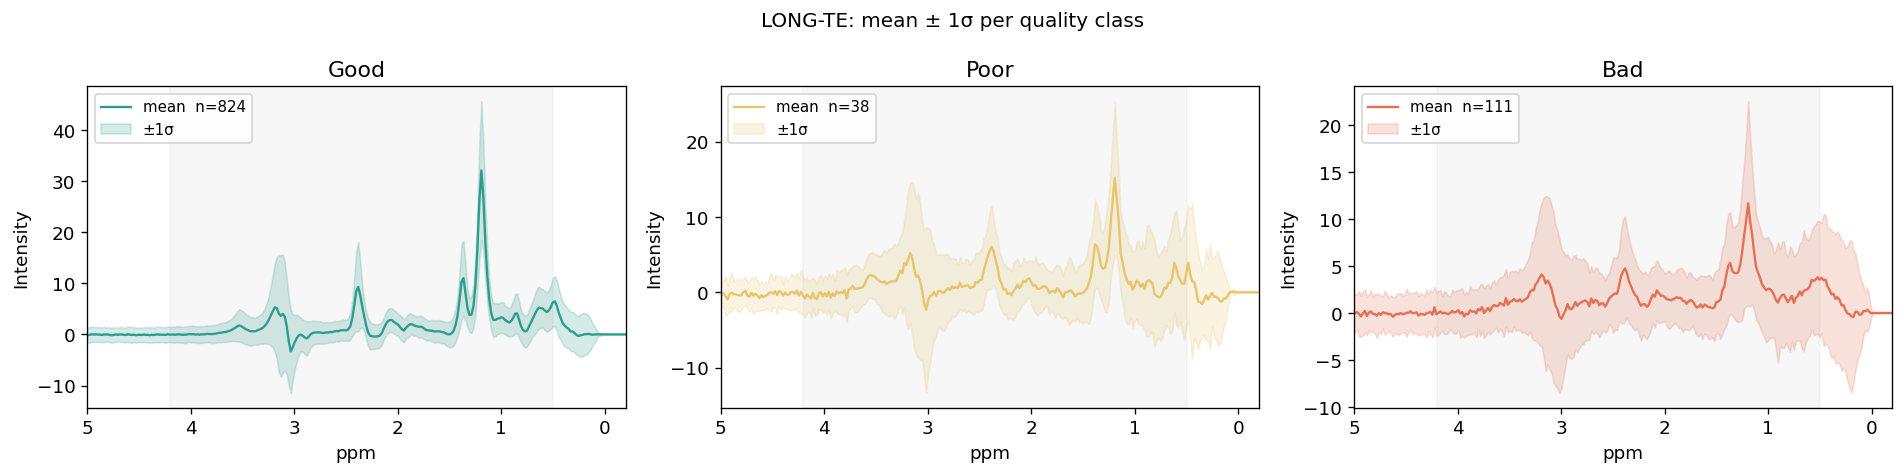

In [8]:
def mean_spectra_plot(df, te_label):
    grp = df[df["echo_time"] == te_label]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"{te_label.upper()}-TE: mean ± 1σ per quality class", fontsize=12)
    for ax, quality in zip(axes, QUALITY_ORDER):
        sub   = np.vstack(grp[grp["quality"] == quality]["spectrum"].values)
        mu, sd = sub.mean(axis=0), sub.std(axis=0)
        color = QUALITY_COLORS[quality]
        ax.plot(PPM, mu, color=color, lw=1.4, label=f"mean  n={len(sub)}")
        ax.fill_between(PPM, mu - sd, mu + sd, color=color, alpha=0.2, label="±1σ")
        ax.invert_xaxis(); ax.set_xlim(5.0, -0.2)
        ax.set_xlabel("ppm"); ax.set_ylabel("Intensity")
        ax.set_title(quality); ax.legend(fontsize=9)
        ax.axvspan(0.5, 4.2, alpha=0.06, color="gray")
    plt.tight_layout()
    plt.savefig(f"mean_spectra_{te_label}TE.png", bbox_inches="tight")
    plt.show()

mean_spectra_plot(all_df, "short")
mean_spectra_plot(all_df, "long")

---
## 6. Artefact-difference spectrum

Mean(Bad) − Mean(Good): shows the ppm regions where artefacts add or suppress energy. Useful as a spatial attention prior for generation models.

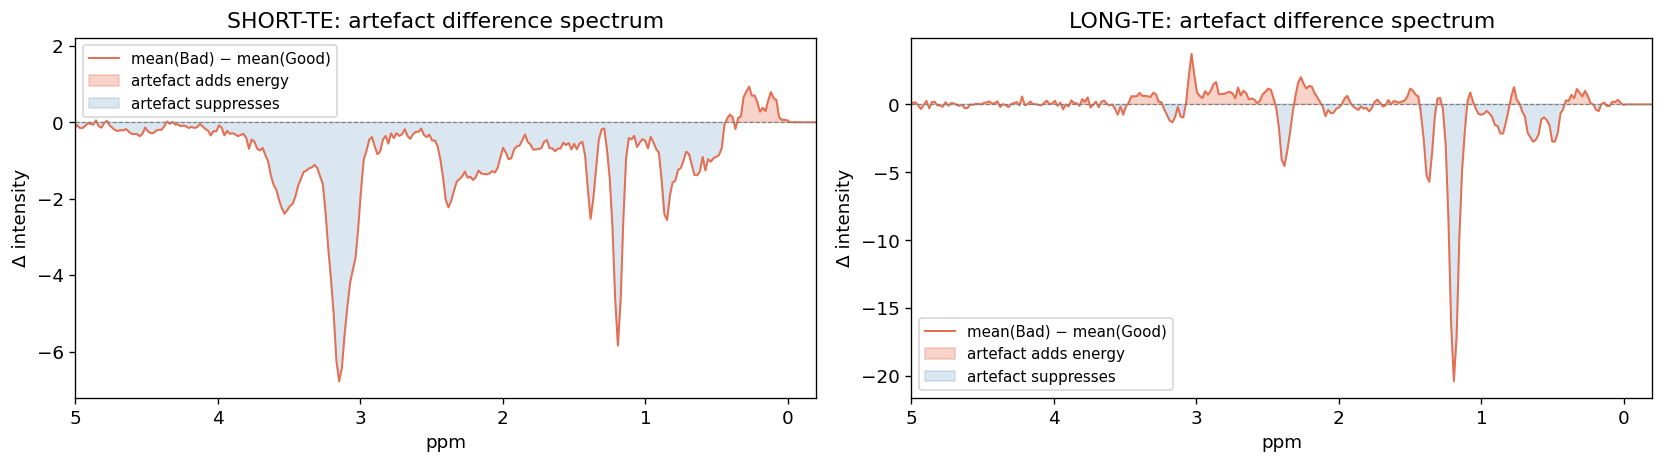

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, te in zip(axes, ["short", "long"]):
    grp = all_df[all_df["echo_time"] == te]
    good_mu = np.vstack(grp[grp["quality"]=="Good"]["spectrum"].values).mean(axis=0)
    bad_mu  = np.vstack(grp[grp["quality"]=="Bad"]["spectrum"].values).mean(axis=0)
    diff    = bad_mu - good_mu
    ax.plot(PPM, diff, color="#e76f51", lw=1.2, label="mean(Bad) − mean(Good)")
    ax.axhline(0, color="gray", lw=0.7, ls="--")
    ax.fill_between(PPM, 0, diff, where=diff > 0, alpha=0.3, color="#e76f51", label="artefact adds energy")
    ax.fill_between(PPM, 0, diff, where=diff < 0, alpha=0.2, color="steelblue", label="artefact suppresses")
    ax.invert_xaxis(); ax.set_xlim(5.0, -0.2)
    ax.set_xlabel("ppm"); ax.set_ylabel("Δ intensity")
    ax.set_title(f"{te.upper()}-TE: artefact difference spectrum"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("artefact_difference_spectrum.png", bbox_inches="tight")
plt.show()

---
## 7. Quality metric distributions (SNR, WBW, QUEST RMSE)

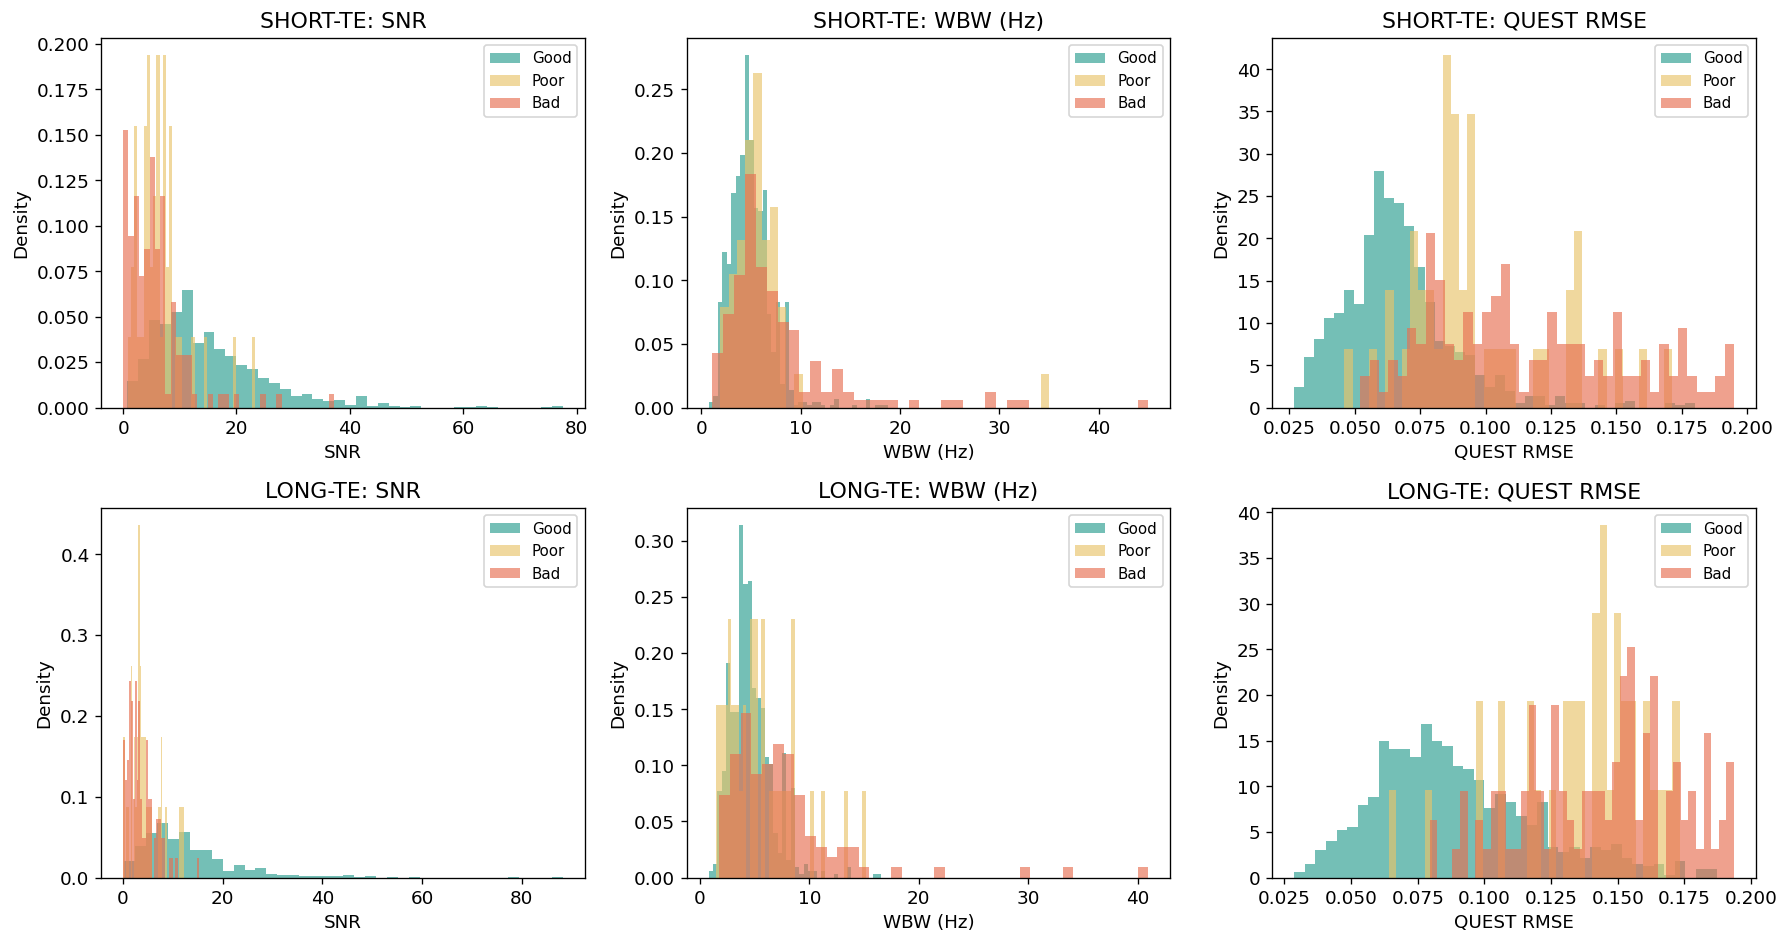

Median per quality class:
                      snr    wbw  quest_rmse
echo_time quality                           
long      Bad       2.972  6.385       0.149
          Good     10.796  4.390       0.084
          Poor      3.496  4.865       0.143
short     Bad       4.780  5.855       0.108
          Good     12.614  4.700       0.064
          Poor      5.924  5.510       0.089


In [10]:
metrics = [("snr","SNR"), ("wbw","WBW (Hz)"), ("quest_rmse","QUEST RMSE")]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row_i, te in enumerate(["short","long"]):
    grp = all_df[all_df["echo_time"]==te]
    for col_i, (col, label) in enumerate(metrics):
        ax = axes[row_i, col_i]
        for quality in QUALITY_ORDER:
            sub = grp[grp["quality"]==quality][col]
            sub = sub[sub > 0] if col in ("snr","wbw") else sub
            ax.hist(sub, bins=40, color=QUALITY_COLORS[quality], alpha=0.65, label=quality, density=True)
        ax.set_xlabel(label); ax.set_ylabel("Density")
        ax.set_title(f"{te.upper()}-TE: {label}"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("quality_metric_distributions.png", bbox_inches="tight")
plt.show()

print("Median per quality class:")
print(
    all_df[all_df["snr"]>0]
    .groupby(["echo_time","quality"])[["snr","wbw","quest_rmse"]]
    .median().round(3).to_string()
)

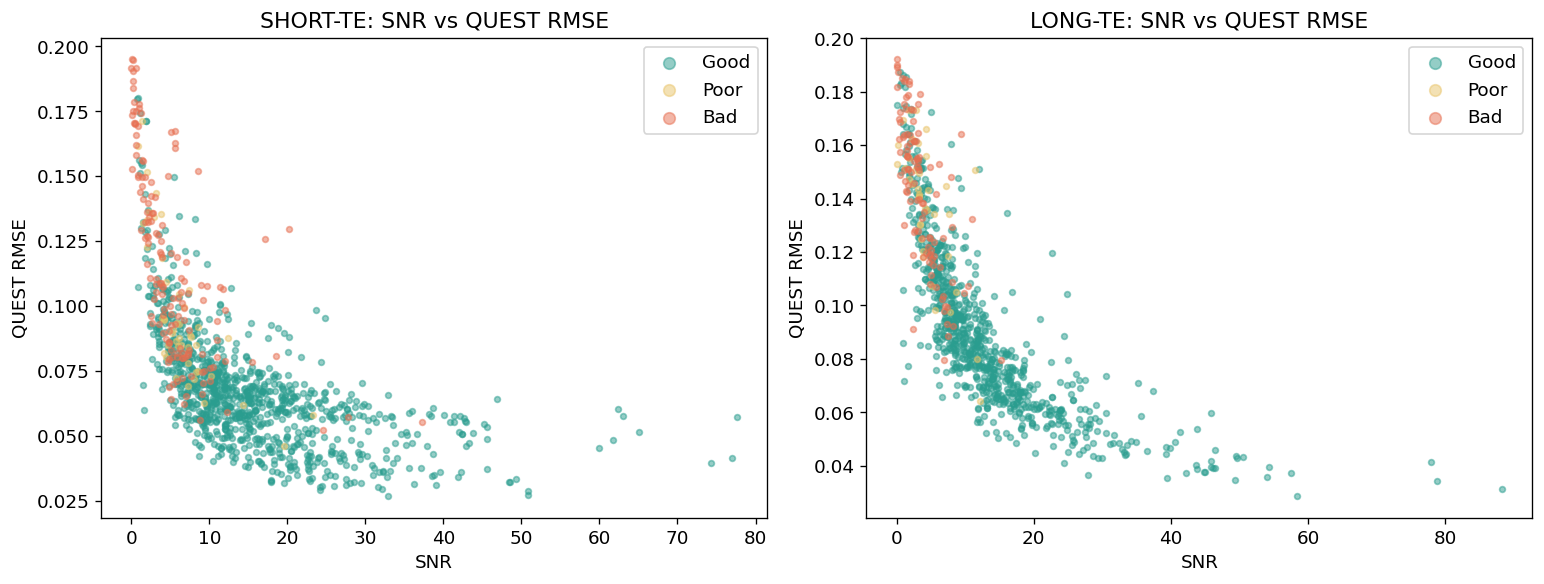

In [11]:
# SNR vs RMSE scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, te in zip(axes, ["short","long"]):
    grp = all_df[(all_df["echo_time"]==te) & (all_df["snr"]>0)]
    for quality in QUALITY_ORDER:
        sub = grp[grp["quality"]==quality]
        ax.scatter(sub["snr"], sub["quest_rmse"], c=QUALITY_COLORS[quality], s=12, alpha=0.5, label=quality)
    ax.set_xlabel("SNR"); ax.set_ylabel("QUEST RMSE")
    ax.set_title(f"{te.upper()}-TE: SNR vs QUEST RMSE"); ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("snr_vs_rmse.png", bbox_inches="tight")
plt.show()

---
## 8. Multi-voxel cases and TE pairing

In [12]:
print("Multi-voxel cases (eTumour short-TE)")
et_short = all_df[(all_df["dataset"]=="eTumour") & (all_df["echo_time"]=="short")]
case_counts = et_short["case_id"].value_counts()
multi = case_counts[case_counts > 1]
print(f"  Cases with >1 spectrum: {len(multi)}  (max {case_counts.max()} per case)")

mixed = [
    {"case_id":cid, "qualities":list(g["quality"]), "tissue":g["tissue_code"].iloc[0]}
    for cid, g in et_short.groupby("case_id") if g["quality"].nunique() > 1
]
print(f"  Cases with mixed quality across voxels: {len(mixed)}")
print("  (same patient, different artefact level — valuable for generation)")
for r in mixed[:4]:
    print(f"    {r['case_id']} ({r['tissue']}): {r['qualities']}")

print()
short_cases = set(all_df[all_df["echo_time"]=="short"]["case_id"])
long_cases  = set(all_df[all_df["echo_time"]=="long"]["case_id"])
print(f"Cross-TE pairs available: {len(short_cases & long_cases)}")
print(f"Short-TE only: {len(short_cases - long_cases)}")
print(f"Long-TE only:  {len(long_cases - short_cases)}")

Multi-voxel cases (eTumour short-TE)
  Cases with >1 spectrum: 34  (max 2 per case)
  Cases with mixed quality across voxels: 7
  (same patient, different artefact level — valuable for generation)
    et2024 (gl): [np.str_('Good'), np.str_('Poor')]
    et2294 (a2): [np.str_('Good'), np.str_('Poor')]
    et3087 (oa): [np.str_('Bad'), np.str_('Good')]
    et3234 (mm): [np.str_('Bad'), np.str_('Good')]

Cross-TE pairs available: 916
Short-TE only: 155
Long-TE only:  40


---
## 9. Tissue-type distribution and artefact rates

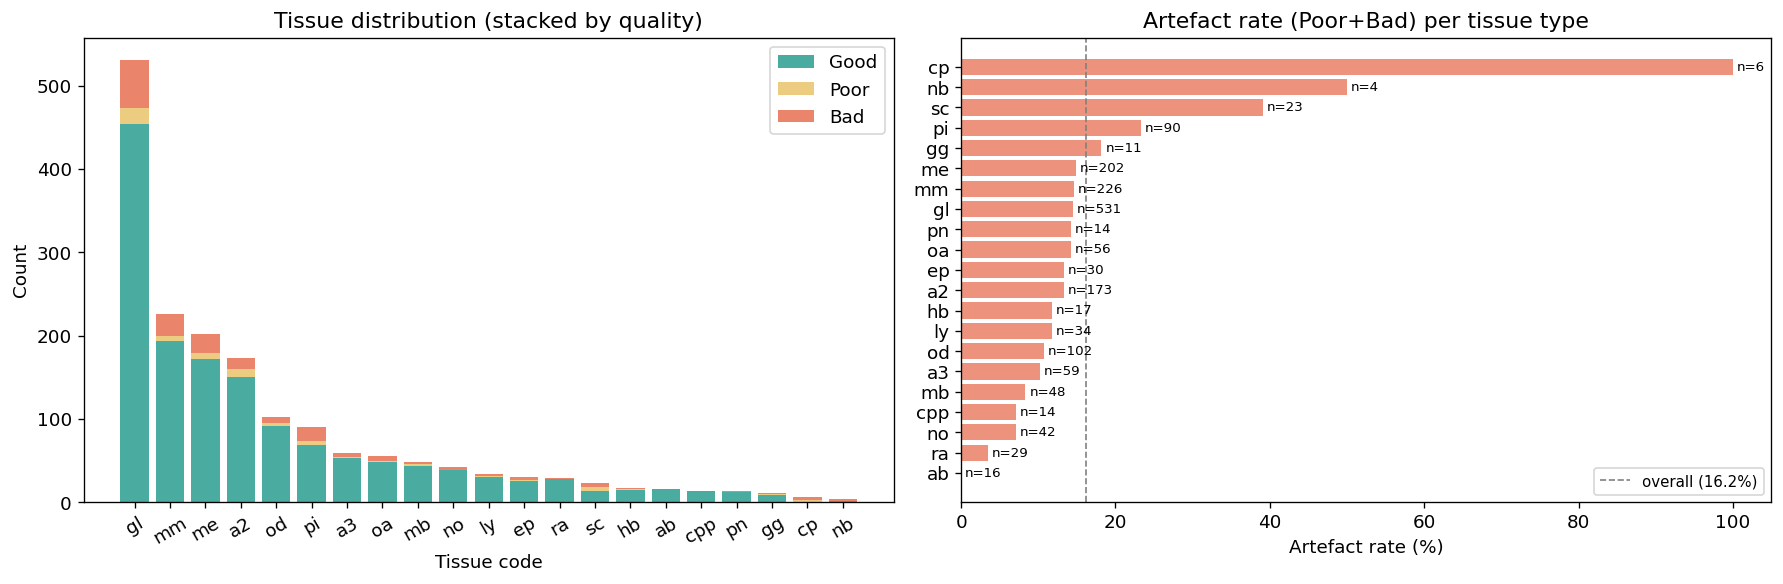

In [13]:
labelled = all_df[all_df["tissue_code"].apply(is_labelled)]
order    = labelled["tissue_code"].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar: count per tissue × quality
ax = axes[0]
bottoms = np.zeros(len(order))
for quality in QUALITY_ORDER:
    counts = [len(labelled[(labelled["tissue_code"]==tc) & (labelled["quality"]==quality)]) for tc in order]
    ax.bar(order, counts, bottom=bottoms, label=quality, color=QUALITY_COLORS[quality], alpha=0.85)
    bottoms += np.array(counts, dtype=float)
ax.set_xlabel("Tissue code"); ax.set_ylabel("Count")
ax.set_title("Tissue distribution (stacked by quality)"); ax.legend()
ax.tick_params(axis="x", rotation=30)

# Artefact rate per tissue
ax = axes[1]
art_rate = (
    labelled.groupby("tissue_code")["is_artefactual"]
    .agg(["mean","count"]).rename(columns={"mean":"rate","count":"n"})
    .sort_values("rate", ascending=True)
)
bars = ax.barh(art_rate.index, art_rate["rate"]*100, color="#e76f51", alpha=0.75)
for bar, (idx, row) in zip(bars, art_rate.iterrows()):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"n={int(row.n)}", va="center", fontsize=8)
ax.set_xlabel("Artefact rate (%)")
ax.set_title("Artefact rate (Poor+Bad) per tissue type")
ax.axvline(100*all_df["is_artefactual"].mean(), color="gray", ls="--", lw=1,
           label=f"overall ({100*all_df.is_artefactual.mean():.1f}%)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("tissue_distribution.png", bbox_inches="tight")
plt.show()

---
## 10. Normalisation comparison

Raw amplitudes vary substantially. Compare three strategies before committing to one for training.

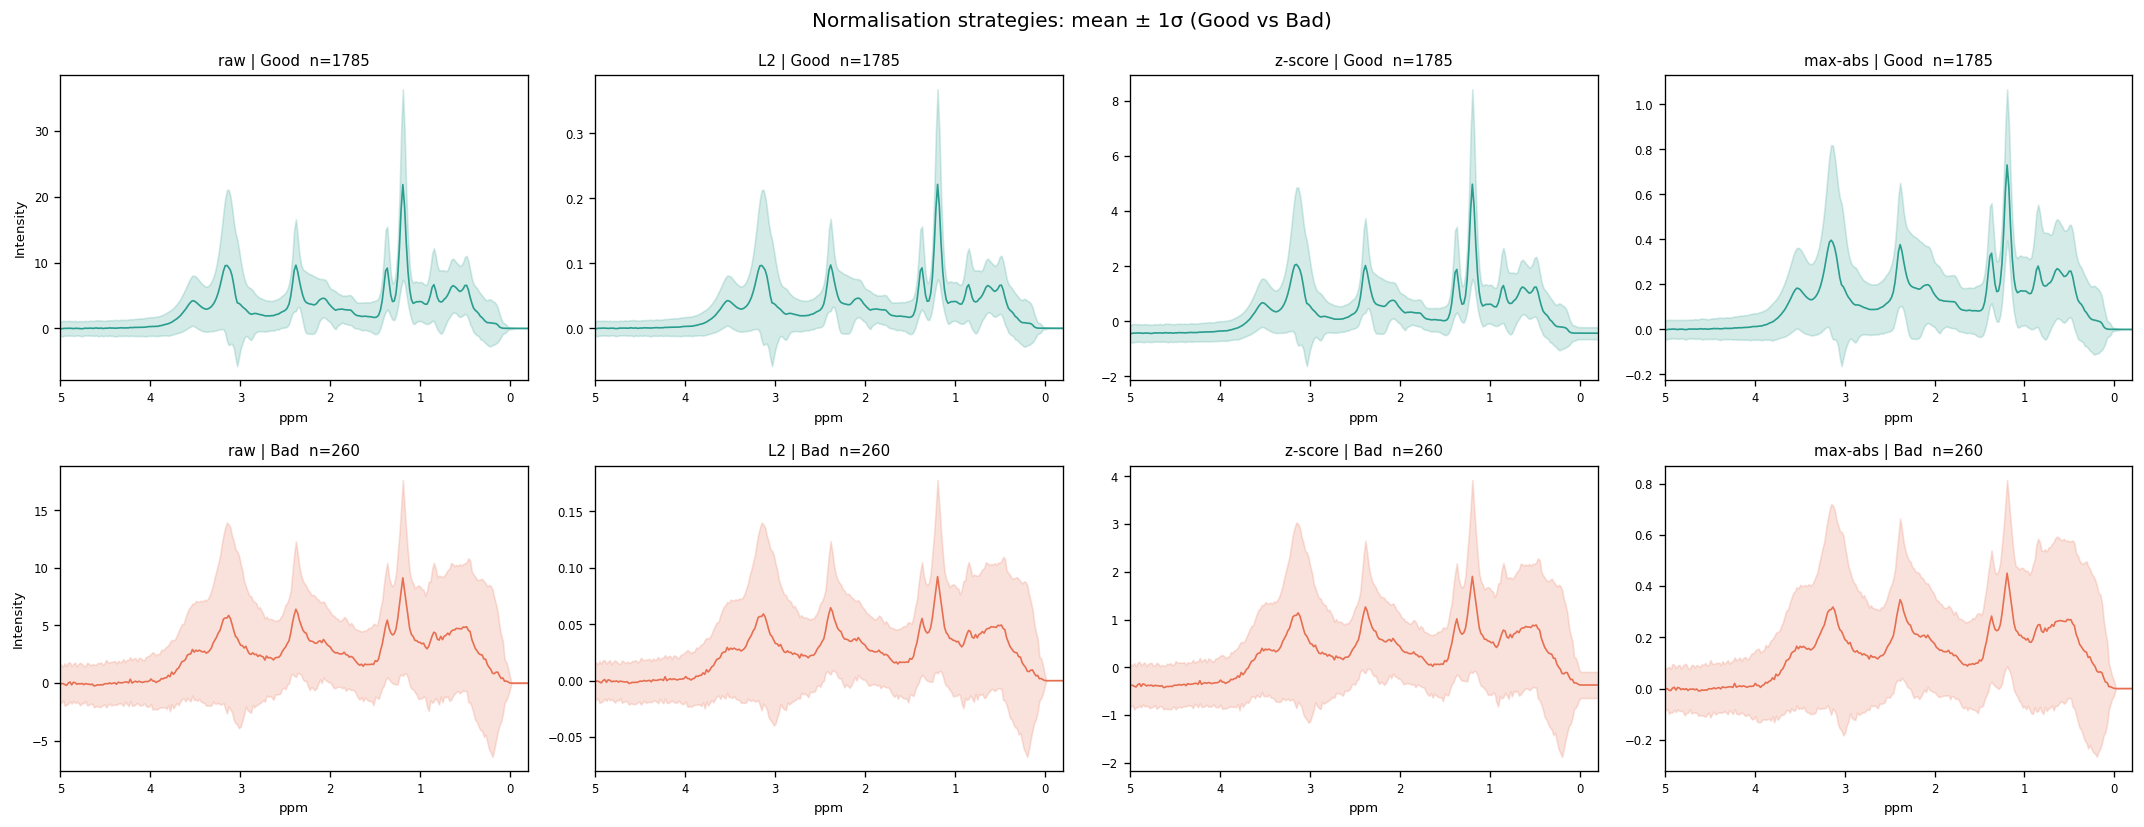

Amplitude consistency (lower std = more uniform scale):
  raw         : mean |max|=27.844  std |max|=10.077
  L2          : mean |max|=0.282  std |max|=0.102
  z-score     : mean |max|=6.528  std |max|=2.283
  max-abs     : mean |max|=1.000  std |max|=0.000


In [14]:
raw_spectra = np.vstack(all_df["spectrum"].values).astype(np.float32)

def norm_l2(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True); norms[norms==0] = 1; return X / norms
def norm_zscore(X):
    mu = X.mean(axis=1, keepdims=True); sd = X.std(axis=1, keepdims=True); sd[sd==0]=1; return (X-mu)/sd
def norm_maxabs(X):
    mx = np.abs(X).max(axis=1, keepdims=True); mx[mx==0]=1; return X/mx

norms = {"raw": raw_spectra, "L2": norm_l2(raw_spectra),
         "z-score": norm_zscore(raw_spectra), "max-abs": norm_maxabs(raw_spectra)}

qlabels = all_df["quality"].values
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle("Normalisation strategies: mean ± 1σ (Good vs Bad)", fontsize=12)

for col_i, (norm_name, X) in enumerate(norms.items()):
    for row_i, quality in enumerate(["Good", "Bad"]):
        ax = axes[row_i, col_i]
        mask = qlabels == quality
        sub  = X[mask]; mu = sub.mean(axis=0); sd = sub.std(axis=0)
        color = QUALITY_COLORS[quality]
        ax.plot(PPM, mu, color=color, lw=1.0)
        ax.fill_between(PPM, mu-sd, mu+sd, color=color, alpha=0.2)
        ax.invert_xaxis(); ax.set_xlim(5.0, -0.2)
        ax.set_title(f"{norm_name} | {quality}  n={mask.sum()}", fontsize=9)
        ax.tick_params(labelsize=7); ax.set_xlabel("ppm", fontsize=8)
        if col_i == 0: ax.set_ylabel("Intensity", fontsize=8)

plt.tight_layout()
plt.savefig("normalisation_comparison.png", bbox_inches="tight")
plt.show()

print("Amplitude consistency (lower std = more uniform scale):")
for name, X in norms.items():
    mx = np.abs(X).max(axis=1)
    print(f"  {name:12s}: mean |max|={mx.mean():.3f}  std |max|={mx.std():.3f}")

---
## 11. Export

In [15]:
spectra_matrix = np.vstack(all_df["spectrum"].values).astype(np.float32)
meta_cols      = [c for c in all_df.columns if c != "spectrum"]
meta_df        = all_df[meta_cols].reset_index(drop=True)

assert len(meta_df) == spectra_matrix.shape[0]

meta_df.to_csv("mrs_unified_metadata.csv", index=False)
np.save("mrs_unified_spectra.npy", spectra_matrix)

print(f"mrs_unified_metadata.csv  — {meta_df.shape[0]:,} rows × {meta_df.shape[1]} cols")
print(f"mrs_unified_spectra.npy   — {spectra_matrix.shape}  float32")
print()
print(f"Total:       {len(all_df):,}")
print(f"Short-TE:    {(all_df.echo_time=='short').sum():,}")
print(f"Long-TE:     {(all_df.echo_time=='long').sum():,}")
print(f"eTumour:     {(all_df.dataset=='eTumour').sum():,}")
print(f"INTERPRET:   {(all_df.dataset=='INTERPRET').sum():,}")
print(f"Quality:     {dict(all_df.quality.value_counts())}")
print(f"Artefactual: {all_df.is_artefactual.sum():,} ({100*all_df.is_artefactual.mean():.1f}%)")
print(f"Tissue OK:   {tc_ok.sum():,} / {len(all_df):,} ({100*tc_ok.mean():.1f}%)")

mrs_unified_metadata.csv  — 2,129 rows × 14 cols
mrs_unified_spectra.npy   — (2129, 512)  float32

Total:       2,129
Short-TE:    1,156
Long-TE:     973
eTumour:     1,347
INTERPRET:   782
Quality:     {np.str_('Good'): np.int64(1785), np.str_('Bad'): np.int64(260), np.str_('Poor'): np.int64(84)}
Artefactual: 344 (16.2%)
Tissue OK:   1,727 / 2,129 (81.1%)


---
## 12. Issues report

In [16]:
issues = []

tc_missing = all_df[~tc_ok]
if len(tc_missing):
    issues.append((
        "TISSUE — unlabelled rows",
        f"{len(tc_missing)} rows have no tissue code. Quality: {dict(tc_missing.quality.value_counts())}. "
        "Still usable for quality-only modelling. "
        "Recovery options: (a) check if a longer eTumour DB export is available; "
        "(b) nearest-neighbour imputation from labelled spectra."
    ))

interp_rows = all_df[all_df["dataset"]=="INTERPRET"]
interp_miss = (~interp_rows["tissue_code"].apply(is_labelled)).sum()
if interp_miss:
    issues.append((
        "TISSUE — INTERPRET gaps",
        f"{interp_miss} INTERPRET rows missing tissue: their case numbers don't appear in "
        "1TE-ShortMRS_corregido_.xml (304 cases). A complete INTERPRET XML may exist — ask supervisor."
    ))

zero_snr = (all_df["snr"] == 0).sum()
if zero_snr:
    issues.append((
        "SNR — missing values",
        f"{zero_snr} rows have SNR=0. Options: (a) compute from noise floor in spectrum "
        "(−2.7 to −1.5 ppm region); (b) impute from per-quality median."
    ))

vc = all_df["quality"].value_counts()
ratio = vc.get("Good",1) / max(1, min(vc.get("Poor",1), vc.get("Bad",1)))
if ratio > 5:
    issues.append((
        "BALANCE — class imbalance",
        f"Good:{vc.get('Good',0)}  Poor:{vc.get('Poor',0)}  Bad:{vc.get('Bad',0)}  ratio≈{ratio:.0f}×. "
        "For generation: train a separate model per quality class, or use weighted loss."
    ))

issues.append((
    "CODE — convex_nmf.py Python 2",
    "Replace `print 'x'` with `print('x')` throughout before running NMF extraction."
))

print(f"{len(issues)} issues:\n")
for i, (title, detail) in enumerate(issues, 1):
    print(f"{i}. [{title}]\n   {detail}\n")

5 issues:

1. [TISSUE — unlabelled rows]
   402 rows have no tissue code. Quality: {np.str_('Good'): np.int64(307), np.str_('Bad'): np.int64(78), np.str_('Poor'): np.int64(17)}. Still usable for quality-only modelling. Recovery options: (a) check if a longer eTumour DB export is available; (b) nearest-neighbour imputation from labelled spectra.

2. [TISSUE — INTERPRET gaps]
   247 INTERPRET rows missing tissue: their case numbers don't appear in 1TE-ShortMRS_corregido_.xml (304 cases). A complete INTERPRET XML may exist — ask supervisor.

3. [SNR — missing values]
   4 rows have SNR=0. Options: (a) compute from noise floor in spectrum (−2.7 to −1.5 ppm region); (b) impute from per-quality median.

4. [BALANCE — class imbalance]
   Good:1785  Poor:84  Bad:260  ratio≈21×. For generation: train a separate model per quality class, or use weighted loss.

5. [CODE — convex_nmf.py Python 2]
   Replace `print 'x'` with `print('x')` throughout before running NMF extraction.



---
## 13. Fast reload

In [5]:
meta    = pd.read_csv("mrs_unified_metadata.csv")
spectra = np.load("mrs_unified_spectra.npy")      # float32, (N, 512)
PPM     = np.linspace(-2.7, 7.1, 512)
#
# Useful masks:
#   short_mask    = meta["echo_time"] == "short"
#   art_mask      = meta["is_artefactual"] == 1
#   bad_mask      = meta["quality"] == "Bad"
#   gl_mask       = meta["tissue_code"] == "gl"
#   tissue_mask   = meta["tissue_code"].notna() & ~meta["tissue_code"].isin(["unknown","nan"])
#
# Example — artefactual short-TE glioblastoma spectra:
#   X = spectra[short_mask & art_mask & gl_mask]

In [6]:
spectra.shape, meta.shape

((2129, 512), (2129, 14))

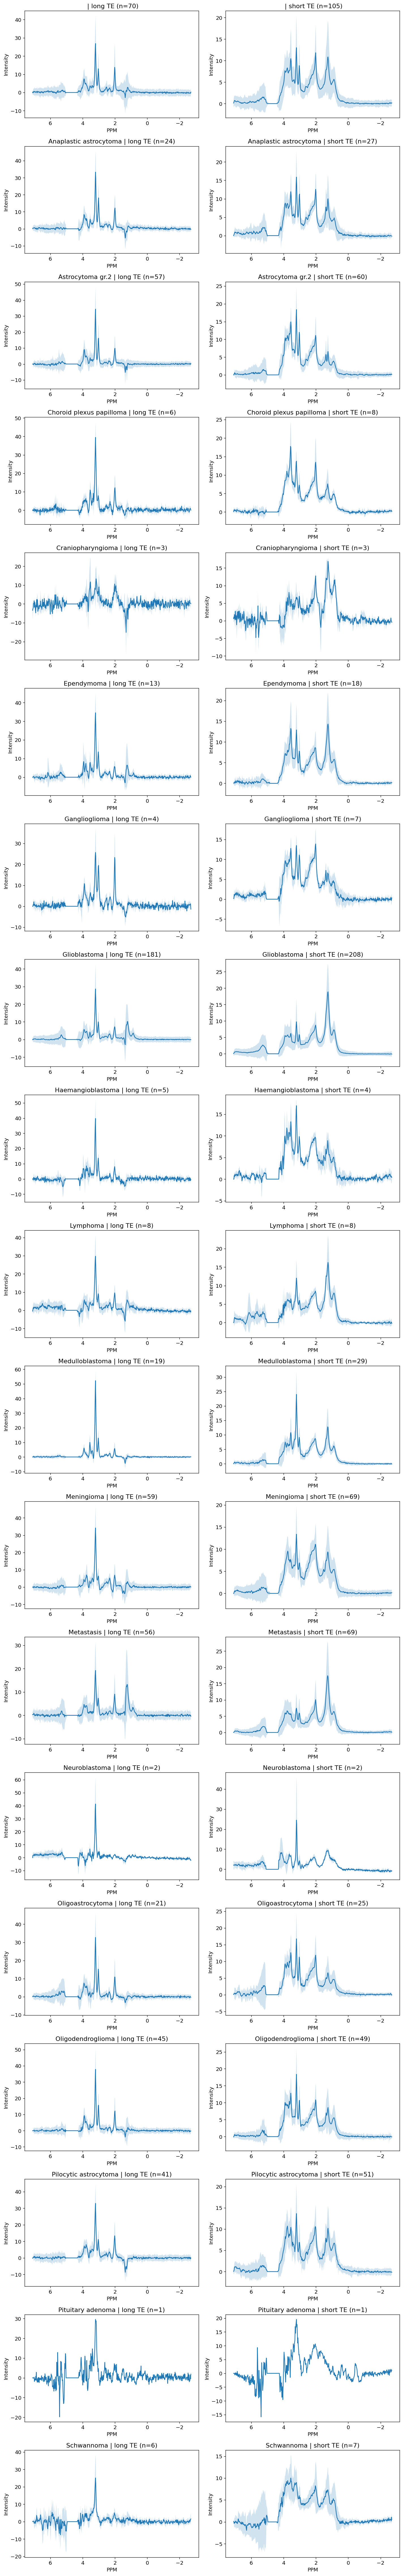

In [47]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

# ---- CONFIG ----
xml_path = "etumour_consolidated.xml"  # <-- change this

# ---- PARSE XML ----
tree = ET.parse(xml_path)
root = tree.getroot()

data_by_class = {}

for case in root.findall("Case"):
    pathology = case.find("Pathology")
    tissue = pathology.attrib["tissue_name"]
    
    for spectrum in case.findall("Spectrum"):
        echo = spectrum.attrib["echo_time"]  # <-- key addition
        
        points = np.array(list(map(float, spectrum.find("Points").text.split())))
        points = points[::-1]  # <-- fix

        
        key = (tissue, echo)
        data_by_class.setdefault(key, []).append(points)

# ---- COMPUTE MEAN + STD ----
stats = {}
for tissue, spectra in data_by_class.items():
    spectra = np.vstack(spectra)
    stats[tissue] = {
        "mean": spectra.mean(axis=0),
        "std": spectra.std(axis=0),
        "n": spectra.shape[0]
    }

# ---- PPM AXIS ----
params = root.find(".//Parameters")
ppm = np.linspace(
    float(params.attrib["FirstPPM"]),
    float(params.attrib["LastPPM"]),
    int(params.attrib["PointsNumber"])
)

# ---- MULTIPLOT ----
n_classes = len(stats)
# ---- ORGANISE KEYS ----
# stats keys are (tissue, echo)
tissues = sorted(set([k[0] for k in stats.keys()]))

te_order = ["long", "short"]  # <-- enforce LTE first

nrows = len(tissues)
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)

# ---- PLOT WITH CONTROLLED POSITIONS ----
for i, tissue in enumerate(tissues):
    for j, echo in enumerate(te_order):
        ax = axes[i, j]
        
        key = (tissue, echo)
        
        if key not in stats:
            fig.delaxes(ax)
            continue
        
        s = stats[key]
        mean, std, n = s["mean"], s["std"], s["n"]
        
        ax.plot(ppm, mean)
        ax.fill_between(ppm, mean - std, mean + std, alpha=0.2)
        
        ax.set_title(f"{tissue} | {echo} TE (n={n})")
        ax.invert_xaxis()
        ax.set_xlabel("PPM")
        ax.set_ylabel("Intensity")

plt.tight_layout()
plt.show()

In [44]:
n = 0
for k, v in stats.items():
    v = v.values()
    print(list(v)[2])
    n += list(v)[2]

print(n)

389
125
128
46
117
94
11
31
92
51
175
9
16
13
48
14
6
2
4
1371


-----------------------------------

# manual attempt